# Evaluate and Compare different Model weights

<b>Author:</b> Annalena Weissert\
<b>Last Edited:</b> 20 July 2026 

<b>Input:</b> Trained Model weights, provided in TrainingOutput/ModelParams\
<b>Output:</b> Graphics and tables evaluationg training performance

<b>Note: </b> Commands where (relative) paths or values may need to be adjusted are marked with '#!'. By default, this file uses the example data but the real trained weights.

In [1]:
import torch
from torchvision import models # Assess Resnet model
from byol_pytorch import BYOL  # BYOL model/model

import numpy as np
from numpy.linalg import norm # for cosine simlarity (Comparison)
import sklearn.metrics as metrics # For ROC Curve

import matplotlib.pyplot as plt # For visualization
from matplotlib.gridspec import GridSpec # For subplot layout
import matplotlib.lines as lines # Add Lines to plot

# Data accessing and handling
import os

In [2]:
## Path settings for Example Data
processed_data_path = "ExampleData_Processed"                  #! Relative path to the folder containing the processed .pt data files
labeled_tumors = ["ExampleTumor5.pt","ExampleTumor6.pt"]       #! Define names of validation tumors. Training progress will be tracked on these.
label_paths = ["ExampleData_Labels/Labels_ExampleTumor5.pt","ExampleData_Labels/Labels_ExampleTumor6.pt"]   #! Relative paths to the label files correpsonding to each validation tumor                                                                          
mz_path = "ExampleData_Processed/00mz_names.pt"                #! path and name to the .pt file containing the names of all m/z-values

## Path settings for Real Data
#processed_data_path = "Processed_Data"  
#labeled_tumors = ['Edi3-Metastase-M1-Lu-Left.pt', 'Primaer-Tumor-M18.pt', 'Rezidiv-Tumor-M22.pt']     
#label_paths = ['Labels/Labels_M1L.pt', 'Labels/Labels_P18.pt', 'Labels/Labels_R22.pt']                                                                             
#mz_path = "Processed_Data/00mz_names.pt" #! path and name to the .pt file containing the names of all m/z-values

In [3]:
## Initialize the three versions seperately to compare later
model_pretrained = models.resnet50(weights='DEFAULT')
model_default = BYOL(models.resnet50(weights='DEFAULT'), image_size = 232, hidden_layer = 'avgpool')
model_custom = BYOL(models.resnet50(weights='DEFAULT'), image_size = 232, hidden_layer = 'avgpool')

In [ ]:
# Load trained weights for default and custom 
# Trained weights as in paper
model_default.load_state_dict(torch.load("TrainingOutput/ModelParams/ResNet50_FullBYOL-default_training-21_01_2026.pt", map_location=torch.device('cpu')))  #! Adjust name 
model_custom.load_state_dict(torch.load("TrainingOutput/ModelParams/ResNet50_FullBYOL-custom_training-19_01_2026.pt", map_location=torch.device('cpu')))  #! Adjust name

#! Trained on Example Data
#model_custom.load_state_dict(torch.load("TrainingOutput/ModelParams/ResNet50_BestParams_FullBYOL-123-20_07_2026.pt", map_location=torch.device('cpu'))) 

<All keys matched successfully>

In [5]:
## mz value names
mz = torch.load(mz_path, weights_only=False)  #! change path to m/z-name file if necessary
mz = np.concatenate((['Ref'],np.round(mz[1:].astype(float),3))) # Round to 3 digits (2 digits is not identifiable)
num_mz = len(mz)

In [6]:
mini_batch = 20 
preprocess = models.ResNet50_Weights.DEFAULT.transforms() # preprocess pipeline of ResNet (also used in training)

## Function that embedds all tumor images with a given model
def feature_prediction(Tumor, model, mlp_true = True): 
    num = Tumor.shape[0]
    features = np.zeros((num, np.where(mlp_true,256,2048))) # 256 features after the projector head, 2048 for the "raw" Resnet embedding

     ## Use online encoder in evaluation mode
    if mlp_true:
        model_val = model.online_encoder
    else:
        model_val = torch.nn.Sequential(*list(model.children())[:-1])
   
    model_val.eval()
    ## Prediction
    for batch in range(num // mini_batch):
        with torch.no_grad():
            batch_img = Tumor[ batch * mini_batch: (batch + 1) * mini_batch] 
            batch_img = torch.cat((batch_img, batch_img, batch_img), axis=1) # Tripple the color channel
            batch_img = preprocess(batch_img)
            if mlp_true:
                embedding, _  = model_val(batch_img)
            else: # by default use projection embedding, if mlp_true=False overwrite it with resnet representation instead
                embedding = model_val(batch_img)

            embedding = embedding.detach().numpy()
            embedding = np.squeeze(embedding)

            features[batch * mini_batch:(batch + 1) * mini_batch, :] = embedding 

    # Embedd the last images that aren't included in the batch iteration
    if(num % mini_batch != 0):
        with torch.no_grad():
                batch_img = Tumor[(batch + 1) * mini_batch:] 
                batch_img = torch.cat((batch_img, batch_img, batch_img), axis=1) # Tripple the color channel
                batch_img = preprocess(batch_img)

                #if not mlp_true: # by default use projection embedding, if mlp_true=False overwrite it with resnet representation instead
                if mlp_true:
                    embedding, _  = model_val(batch_img)
                else: 
                    embedding = model_val(batch_img)    
                embedding = embedding.detach().numpy()
                embedding = np.squeeze(embedding)

                features[(batch + 1) * mini_batch:, :] = embedding      

    return features

## Define own Cosine Similarity between a Ref and each img from a batch
def cos_sim_batch(ref, batch):
    n_img = batch.shape[0]
    res_vec = np.zeros(n_img)
    for i in range(n_img):
        res_vec[i] = np.dot(ref, batch[i,:])/(np.linalg.norm(ref)*np.linalg.norm(batch[i,:]))
    return res_vec

## Function to convert labels into color
def col_cvt(input_labels, col_list = ['grey','limegreen','yellow']):
    col_idx = np.array(col_list)
    col_labels= np.array(np.repeat('lightgrey',num_mz), dtype='<U10')
    col_labels[:(len(input_labels))] = col_idx[input_labels] 
    return col_labels

In [7]:
## function to plot best 16 results and AUC curve of all three models. also saves the auc0 value
def compare_tumor_results(tumor_name, label_name):
    M_compare = torch.load("".join([processed_data_path,"/",tumor_name]))

    ## Load and process labels
    M_labels = torch.load(label_name, weights_only=False)
    M_labels = np.array(M_labels)
    M_labels1 = M_labels.copy()
    M_labels1[M_labels1==2] = 1
    M_labels0 = M_labels.copy()
    M_labels0[M_labels0==2] = 0

    ## Calculate features and resulting cosine distance for each model version
    features_pre = feature_prediction(M_compare, model=model_pretrained, mlp_true = False)
    res_pre = cos_sim_batch(features_pre[0], features_pre)
    print("Pre-trained calculated")
    features_def = feature_prediction(M_compare, model=model_default)
    res_def = cos_sim_batch(features_def[0], features_def)
    print("Default calculated")
    features_cust = feature_prediction(M_compare, model=model_custom)
    print("Custom calculated")
    res_cust = cos_sim_batch(features_cust[0], features_cust)

    ## AUC
    fpr0, tpr0, _ =  metrics.roc_curve(M_labels0[1:], res_pre[1:])
    auc_pre = metrics.auc(fpr0, tpr0)
    fpr1, tpr1, _ =  metrics.roc_curve(M_labels0[1:], res_def[1:])
    auc_def = metrics.auc(fpr1, tpr1)
    fpr2, tpr2, _ =  metrics.roc_curve(M_labels0[1:], res_cust[1:])
    auc_cust = metrics.auc(fpr2, tpr2)

    ## Preparation for Plot - Save Top 6 idx and results in matrix for easier access
    idx_matrix = np.array([np.argsort(res_vec)[::-1][:31] for res_vec in [res_pre, res_def, res_cust]])
    if not np.all(idx_matrix[:,0] == np.zeros(3)):
        print("WARNING! At least one reference isn't in first place!") # (optional) Check that the reference is contained 
    res_matrix = np.array([np.sort(res_vec)[::-1][:6] for res_vec in [res_pre, res_def, res_cust]])
    col_labels = col_cvt(M_labels)
    
    top30_1 = np.sum(M_labels1[idx_matrix[:,1:]], axis=1) # dont count ref
    top30_0 = np.sum(M_labels0[idx_matrix[:,1:]], axis=1)

    print("Matches in Top 30, incl. approx (excl. approx) of ", sum(M_labels1[1:]),"(",sum(M_labels0[1:]),")"
    "\npre:",top30_1[0],"(",top30_0[0],")",
    "\ndef:",top30_1[1],"(",top30_0[1],")",
    "\ncust:",top30_1[2],"(",top30_0[2],")")

    # Create figure
    fig = plt.figure(figsize=(15, 6))
    gs = GridSpec(3, 8, figure=fig, width_ratios=[1, 1, 1, 1, 1, 1, 0.5, 3.5 ])  # Note: One small empty colum to create space 

    model_name = ['Pre-trained','Default','Custom']
    model_col = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3', 
                  '#999999', '#e41a1c', '#dede00'] # color blind friendly palette

    # Create small plots (3x6 grid)
    for row in range(3):
        for col in range(6):
            res_idx = idx_matrix[row,col]
            ax = fig.add_subplot(gs[row, col])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.imshow(M_compare[res_idx,0])
            ax.set_title("sim:" + str(round(res_matrix[row,col],3)), fontsize=12)
            ax.text(12,232+14,"mz: "+mz[res_idx], horizontalalignment='left', verticalalignment='top', fontsize=10, backgroundcolor = col_labels[res_idx])
            if col == 0:
                ax.set_ylabel(model_name[row],  fontweight='bold', c=model_col[row])

    # Plot ROC, large on the right
    ax_large = fig.add_subplot(gs[:, 7])

    ax_large.set_title('Receiver Operating Characteristic', fontweight='bold')
    ax_large.plot(fpr0, tpr0, label = 'Pre-trained = %0.3f' % auc_pre, c=model_col[0])
    ax_large.plot(fpr1, tpr1, label = 'Default = %0.3f' % auc_def, c=model_col[1])
    ax_large.plot(fpr2, tpr2, label = 'Custum = %0.3f' % auc_cust, c=model_col[2])

    ax_large.legend(loc = 'lower right', title='AUC', title_fontproperties={'weight':'bold'})
    ax_large.plot([0, 1], [0, 1],'r--')
    ax_large.set_xlim([-0.02, 1])
    ax_large.set_ylim([0, 1.02])
    ax_large.set_ylabel('True Positive Rate')
    ax_large.set_xlabel('False Positive Rate')

    fig.add_artist(lines.Line2D([0.2, 0.2], [0.9, 0.05], linewidth=3, color="black"))

    plt.show()

    return auc_pre, auc_def, auc_cust, res_pre, res_def, res_cust
    

In [8]:
## Function to plot the AUC process over epochs
def plot_auc(res, title):
    fontsize0 = 12
    try:
      stop_idx = min(torch.where(res[:,0,0]==0)[0])
    except:
      stop_idx = 300  
    max_auc = round(float(max(torch.mean(res[:stop_idx,:,0],dim=1))),3)
    max_epoch = int(np.argmax(torch.mean(res[:stop_idx,:,0],dim=1)))
    print("Max P18:",round(float(max(res[:stop_idx,0,0])),3),"at",int(np.argmax(res[:stop_idx,0,0])), 
          "\nMax R22:",round(float(max(res[:stop_idx,1,0])),3),"at",int(np.argmax(res[:stop_idx,1,0])),
          "\nMax M1L:",round(float(max(res[:stop_idx,2,0])),3),"at",int(np.argmax(res[:stop_idx,2,0])))
    print("Max AUC0:", max_auc, "at", max_epoch,"-",res[int(np.argmax(torch.mean(res[:stop_idx,:,0],dim=1))),:,0])
    
    # Maximum Line
    plt.vlines(max_epoch, 0, 1, linestyles ="dashed", colors ="grey")
    plt.text(max_epoch, 0.4, f"Max val. AUC: {max_auc}", rotation = 270, c = "grey", va="center")

    plt.plot(res[:stop_idx,0,0], c="orange") 
    plt.plot(res[:stop_idx,1,0], c="goldenrod") 
    plt.plot(res[:stop_idx,2,0], c="palegoldenrod")

    plt.title(title, fontsize=fontsize0+3)

    plt.text(10,0.2,"Prim 18",c="orange", fontweight="bold", fontsize=fontsize0 )
    plt.text(10,0.15,"Rec 22",c="goldenrod", fontweight="bold", fontsize=fontsize0 )
    plt.text(10,0.1,"Met 1L",c="palegoldenrod", fontweight="bold", fontsize=fontsize0 )
    plt.ylabel('AUC', fontsize=fontsize0)
    plt.xlabel('epoch', fontsize=fontsize0)
    plt.ylim(0,1) 

    

---
Training progress

Max P18: 0.982 at 128 
Max R22: 0.951 at 72 
Max M1L: 0.946 at 142
Max AUC0: 0.953 at 137 - tensor([0.9802, 0.9395, 0.9387])


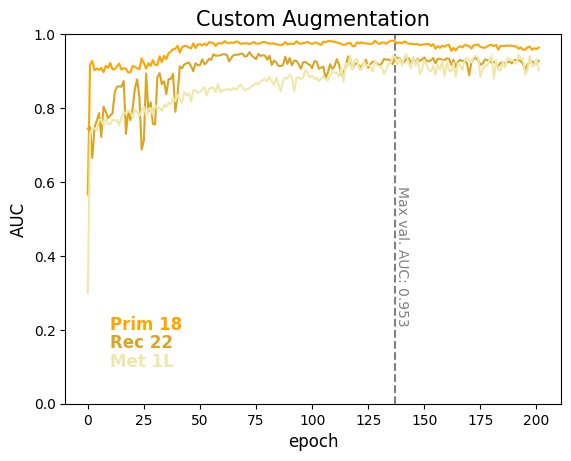

In [9]:
# Custom Training on Real Data
res_custom = torch.load("TrainingOutput/ModelParams/ResNet50_AUC0-190101-19_01_2026.pt", weights_only=False)
plot_auc(res_custom, "Custom Augmentation")

Max P18: 0.907 at 1 
Max R22: 0.935 at 94 
Max M1L: 0.811 at 146
Max AUC0: 0.841 at 146 - tensor([0.8411, 0.8728, 0.8106])


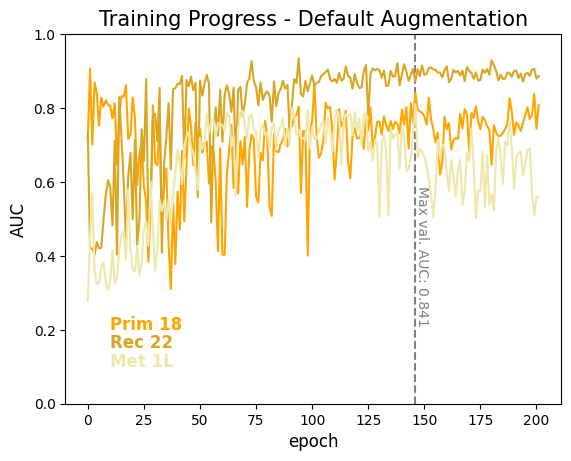

In [10]:
# Default Training on Real Data
res_default = torch.load("TrainingOutput/ModelParams/ResNet50_AUC0-210101-21_01_2026.pt", weights_only=False)
plot_auc(res_default, "Training Progress - Default Augmentation")

----
## Evaluation (Example Tumors, Real Model Weights)

In [11]:
# Vector to save all resulting AUC values for all 3 models (pretrained, default, custom) and 9 mice
num_labeled = len(label_paths)
res_auc = np.zeros((num_labeled ,3))
res_sim = np.zeros((num_labeled ,3,num_mz))

Evaluate First Labeled Tumor 

Pre-trained calculated
Default calculated
Custom calculated
Matches in Top 30, incl. approx (excl. approx) of  13 ( 7 )
pre: 4 ( 1 ) 
def: 8 ( 4 ) 
cust: 13 ( 7 )


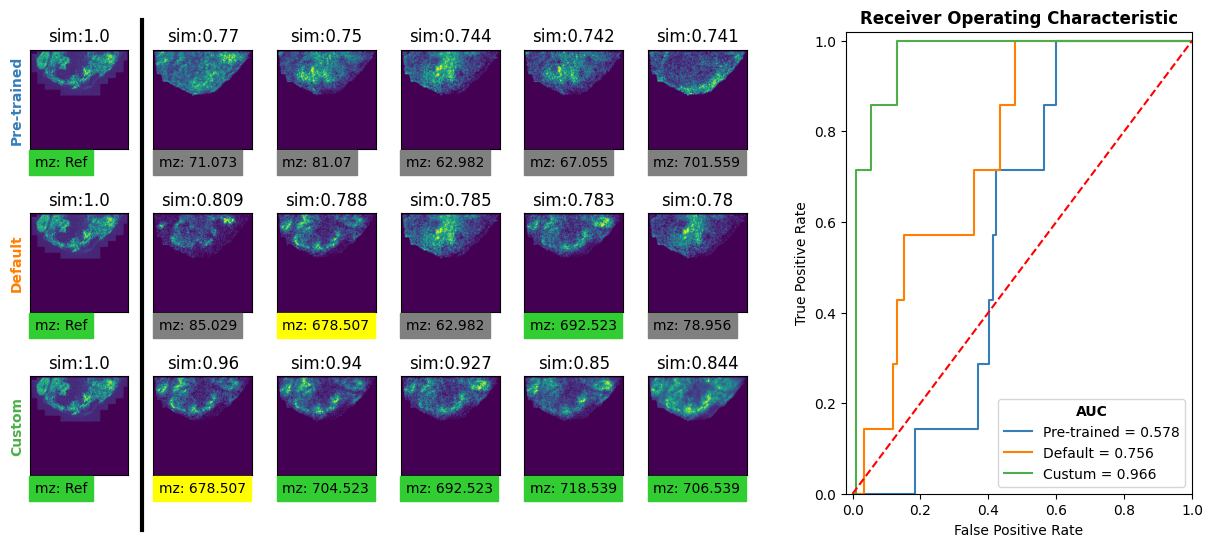

In [12]:
## First Tumor
m_idx = 0

res_tuple = compare_tumor_results(labeled_tumors[m_idx], label_paths[m_idx])
res_auc[m_idx,:] = res_tuple[:3]
res_sim[m_idx,:,:] = res_tuple[3:]

Evaluate Second Labeled Tumor 

Pre-trained calculated
Default calculated
Custom calculated
Matches in Top 30, incl. approx (excl. approx) of  31 ( 8 )
pre: 6 ( 3 ) 
def: 16 ( 7 ) 
cust: 23 ( 8 )


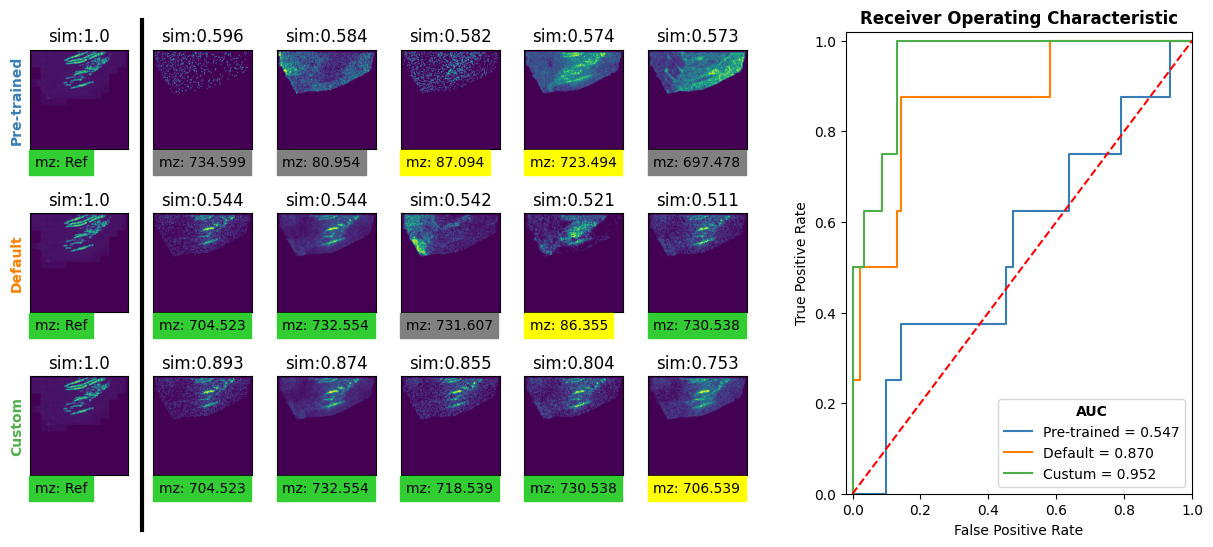

In [13]:
## Second Tumor
m_idx = 1

res_tuple = compare_tumor_results(labeled_tumors[m_idx], label_paths[m_idx])
res_auc[m_idx,:] = res_tuple[:3]
res_sim[m_idx,:,:] = res_tuple[3:]

analogously for other tumors...

In [ ]:
## (optional) SAVE Results 
torch.save(res_auc, "res_auc.pt")
torch.save(res_sim, "res_sim.pt")

---
## Embed ALL Example Tumors in custom network 
Here performed on example data to save calculation time

In [14]:
## Plot mz indices for a range of Tumors
# Input: mz idx list, Tumor_list
# Output: Plot these mz values for the Tumor in Tumor_list (loaded already, to save plotting time)

def plot_top_results(mz_idx_list, Tumors, Tumor_names):
    number_tumor = len(Tumor_names)
    # Add the reference in the begining, if it's not there yet
    if mz_idx_list[0] != 0:
        mz_idx_list = [0] + mz_idx_list
       
    # Create figure
    fig = plt.figure(figsize=(10, 1.2*number_tumor))
    gs = GridSpec(number_tumor, 8, figure=fig, width_ratios=[1, 1, 1, 1, 1, 1, 1, 1 ])  # Note: One small empty colum to create space 

    # Create small plots 
    for row in range(number_tumor):
        for col in range(min(len(mz_idx_list),8)): # Plots less columns for shorter idx list
            #res_idx = idx_matrix[row,col]
            ax = fig.add_subplot(gs[row, col])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.imshow(Tumors[row][mz_idx_list[col],0])
            if row == 0:
                ax.set_title("mz:" + mz[mz_idx_list[col]], fontsize=12)
            #ax.text(12,232+14,"mz: "+mz[res_idx], horizontalalignment='left', verticalalignment='top', fontsize=10, backgroundcolor = col_labels[res_idx])
            if col == 0:
                ax.set_ylabel(Tumor_names[row],  fontweight='bold')#, c=model_col[row])
    # Add a vertical line between Ref and Results
    fig.add_artist(lines.Line2D([0.148, 0.148], [1, 0], linewidth=3, color="black"))

    plt.tight_layout()
    plt.show()
    

Calculate similarity for the custom network for all (example) tumors

In [17]:
import re
from scipy.stats import rankdata # To assign ranks to the resulting matchscores 
import pandas as pd # To create data frames

os.chdir(processed_data_path)
## mz value names
mz = torch.load("00mz_names.pt", weights_only=False)  #! change path to m/z-name file if necessary
mz = np.concatenate((['Ref'],np.round(mz[1:].astype(float),3))) # Round to 3 digits (2 digits is not identifiable)
num_mz = len(mz)

tumor_names = os.listdir()
tumor_names.sort()
tumor_names = tumor_names[1:] #exclude mz-names
name_abbrev = ["".join(re.search('(Tumor[0-9]+)', s).groups()) for s in tumor_names] #! for Example date
#name_abbrev = ["".join(re.search('([MPR]).*-M([0-9]+)(?:-Lu-)*([LRlr]?)', s).groups()) for s in tumor_names] #! regex magic for real data. 
res_sim_all_mice = np.zeros((len(tumor_names),num_mz)) # empty result array

In [18]:
## Embed Tumor and save resulting similaritys in res_sim_all_mice
for idx, mouse_name in enumerate(tumor_names):
    print(round(idx*100/len(tumor_names),1), "%:",mouse_name)
    M_compare = torch.load(mouse_name)

    features_cust = feature_prediction(M_compare, model=model_custom)
    res_cust = cos_sim_batch(features_cust[0], features_cust)
    res_sim_all_mice[idx] = res_cust

0.0 %: ExampleTumor1.pt
16.7 %: ExampleTumor2.pt
33.3 %: ExampleTumor3.pt
50.0 %: ExampleTumor4.pt
66.7 %: ExampleTumor5.pt
83.3 %: ExampleTumor6.pt


In [19]:
### Sort mz-values by average rank over all labeled mice 
rank_scores_all = pd.DataFrame(index=mz, columns=name_abbrev)

# Write Ranks of each Match Score in the data frame
for idx in range(len(tumor_names)):
    rank_scores_all[name_abbrev[idx]] = num_mz - rankdata(res_sim_all_mice[idx,:], method='average')

# (optional) Drop R2 and R10 because they contain measurement errors
#rank_scores_all = rank_scores_all.drop(['R2','R10'],axis=1) #! potentially exclude mice

## Calc mean of remaining
rank_scores_all['mean'] = round(rank_scores_all.mean(axis=1),2)
# Sort by increasing mean and get the best m/z values in order
best_res_all = rank_scores_all.sort_values('mean').iloc[0:150].index
idx_list_all=[]
for mz1 in best_res_all:
    idx_list_all.append(mz.tolist().index(mz1))

## Display Table    
rank_scores_all.sort_values('mean').iloc[1:20] # Exclude 0 as it is the Ref

,Tumor1,Tumor2,Tumor3,Tumor4,Tumor5,Tumor6,mean
692.523,5.0,7.0,50.0,2.0,3.0,10.0,12.83
722.534,10.0,6.0,37.0,1.0,18.0,12.0,14.00
678.507,2.0,5.0,45.0,22.0,1.0,11.0,14.33
718.539,4.0,4.0,71.0,21.0,4.0,3.0,17.83
706.539,7.0,9.0,53.0,28.0,5.0,5.0,17.83
732.554,6.0,2.0,48.0,46.0,6.0,2.0,18.33
704.523,1.0,3.0,70.0,49.0,2.0,1.0,21.00
723.494,14.0,28.0,27.0,9.0,42.0,22.0,23.67
708.553,31.0,13.0,36.0,12.0,27.0,38.0,26.17
730.538,3.0,1.0,67.0,75.0,11.0,4.0,26.83


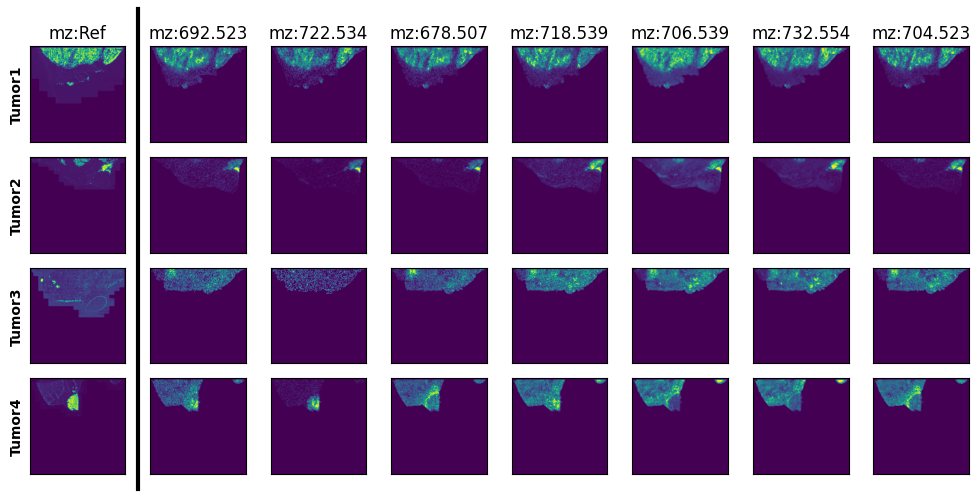

In [20]:
# Load and Plot the first four tumors and the 7 most similar m/z-values (on average)
tumor_list4 = [ torch.load(tumor_names[0]), torch.load(tumor_names[1]), torch.load(tumor_names[2]), torch.load(tumor_names[3])]
plot_top_results(idx_list_all, tumor_list4, name_abbrev[:4])